<a href="https://colab.research.google.com/github/reetu95/cfd-ml-surrogate-heatsink/blob/main/notebooks/01_single_fin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import os

# === STEP 1: Load and Clean the Dataset ===

In [ ]:
csv_path = "combined_output_single_fin.csv"
df = pd.read_csv(csv_path, sep=",", skipinitialspace=True, quotechar='"')

In [ ]:
df.head()

,"cellnumber,","x-coordinate,","y-coordinate,","z-coordinate,",temperature,L
0,"1,","3.846153846E-04,","6.611111111E-03,","9.615384615E-03,",469.883632,30.0
1,"2,","3.846153846E-04,","5.833333333E-03,","9.615384615E-03,",469.908553,30.0
2,"3,","3.846153846E-04,","6.611111111E-03,","8.846153846E-03,",469.883639,30.0
3,"4,","1.153846154E-03,","6.611111111E-03,","9.615384615E-03,",469.883642,30.0
4,"5,","3.846153846E-04,","5.055555556E-03,","9.615384615E-03,",469.930365,30.0


In [ ]:
# Remove trailing commas from string values and column headers
df = df.map(lambda x: x.rstrip(',') if isinstance(x, str) else x)
df.columns = [col.rstrip(',') for col in df.columns]

/tmp/ipython-input-1754524754.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x : x.rstrip(',') if isinstance(x, str) else x)


In [ ]:
df.head()

,cellnumber,x-coordinate,y-coordinate,z-coordinate,temperature,L
0,1,3.846153846E-04,6.611111111E-03,9.615384615E-03,469.883632,30.0
1,2,3.846153846E-04,5.833333333E-03,9.615384615E-03,469.908553,30.0
2,3,3.846153846E-04,6.611111111E-03,8.846153846E-03,469.883639,30.0
3,4,1.153846154E-03,6.611111111E-03,9.615384615E-03,469.883642,30.0
4,5,3.846153846E-04,5.055555556E-03,9.615384615E-03,469.930365,30.0


In [ ]:
# Keep exactly five columns
df = df[['x-coordinate', 'y-coordinate', 'z-coordinate', 'temperature', 'L']]


In [ ]:
df.head()

,x-coordinate,y-coordinate,z-coordinate,temperature,L
0,3.846153846E-04,6.611111111E-03,9.615384615E-03,469.883632,30.0
1,3.846153846E-04,5.833333333E-03,9.615384615E-03,469.908553,30.0
2,3.846153846E-04,6.611111111E-03,8.846153846E-03,469.883639,30.0
3,1.153846154E-03,6.611111111E-03,9.615384615E-03,469.883642,30.0
4,3.846153846E-04,5.055555556E-03,9.615384615E-03,469.930365,30.0


In [ ]:
df.rename(columns={
    'x-coordinate': 'X',
    'y-coordinate': 'Y',
    'z-coordinate': 'Z',
    'temperature': 'T',
    'L':'L'
}, inplace=True)


In [ ]:
# Convert all to numeric (removes object dtype issue)
df[['X', 'Y', 'Z', 'T', 'L']] = df[['X', 'Y', 'Z', 'T', 'L']].apply(pd.to_numeric, errors='coerce')

# === STEP 2: Convert to Numeric and Drop NaNs ===

In [ ]:
#Drop NaNs
df.dropna(inplace=True)


# === STEP 3: Feature Extraction ===

In [ ]:
#Extracting features and targets
X = df['X'].values
Y = df['Y'].values
Z = df['Z'].values
L = df['L'].values
T = df['T'].values

In [ ]:
print("X",X.shape)
print("Y",Y.shape)
print("Z",Z.shape)
print("L",L.shape)
print("T",T.shape)

X (396457,)
Y (396457,)
Z (396457,)
L (396457,)
T (396457,)


In [ ]:
print(X.dtype)

float64


# === STEP 4: Normalization (Z-Score) ===

In [ ]:
X_scaler_mean = np.mean(X)
X_scaler_std = np.std(X)
X_scaled = (X - X_scaler_mean) / X_scaler_std

In [ ]:
Y_scaler_mean = np.mean(Y)
Y_scaler_std = np.std(Y)
Y_scaled = (Y - Y_scaler_mean) / Y_scaler_std

In [ ]:
Z_scaler_mean = np.mean(Z)
Z_scaler_std = np.std(Z)
Z_scaled = (Z - Z_scaler_mean) / Z_scaler_std

In [ ]:
L_scaler_mean = np.mean(L)
L_scaler_std = np.std(L)
L_scaled = (L - L_scaler_mean) / L_scaler_std

In [ ]:
T_scaler_mean = np.mean(T)
T_scaler_std = np.std(T)
T_scaled = (T - T_scaler_mean) / T_scaler_std

# === STEP 5: Train-Test Split ===

In [ ]:
X_temp, X_test, Y_temp, Y_test, Z_temp, Z_test,L_temp,L_test, T_temp, T_test = train_test_split(
    X_scaled, Y_scaled, Z_scaled,L_scaled, T_scaled, test_size=0.2, random_state=42
)

In [ ]:
X_train, X_val, Y_train, Y_val, Z_train, Z_val,L_train,L_val, T_train, T_val = train_test_split(
    X_temp, Y_temp, Z_temp, L_temp,T_temp, test_size=0.2, random_state=42
)

In [ ]:
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])
print("Total samples:", X_train.shape[0] + X_val.shape[0] + X_test.shape[0])

Training samples: 253732
Validation samples: 63433
Test samples: 79292
Total samples: 396457


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0



# === STEP 6: PyTorch Tensors ===

In [ ]:
# Converting numpy arrays into PyTorch tensors (4D input: X, Y, Z,H)
X_train_tensor = torch.FloatTensor(np.column_stack((X_train.reshape(-1,1), Y_train.reshape(-1,1), Z_train.reshape(-1,1),L_train.reshape(-1,1)))).to(device)
Y_train_tensor = torch.FloatTensor(T_train.reshape(-1,1)).to(device)

X_val_tensor = torch.FloatTensor(np.column_stack((X_val.reshape(-1,1), Y_val.reshape(-1,1), Z_val.reshape(-1,1), L_val.reshape(-1,1)))).to(device)
Y_val_tensor = torch.FloatTensor(T_val.reshape(-1,1)).to(device)

X_test_tensor = torch.FloatTensor(np.column_stack((X_test.reshape(-1,1), Y_test.reshape(-1,1), Z_test.reshape(-1,1), L_test.reshape(-1,1)))).to(device)
Y_test_tensor = torch.FloatTensor(T_test.reshape(-1,1)).to(device)

In [ ]:
print(f"Training Data: {X_train_tensor.shape}, {Y_train_tensor.shape}")
print(f"Validation data: {X_val_tensor.shape}, {Y_val_tensor.shape}")
print(f"Test data: {X_test_tensor.shape}, {Y_test_tensor.shape}")

Training Data: torch.Size([253732, 4]), torch.Size([253732, 1])
Validation data: torch.Size([63433, 4]), torch.Size([63433, 1])
Test data: torch.Size([79292, 4]), torch.Size([79292, 1])


# === STEP 7: Neural Network Architecture ===

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()

        # Just make it deeper with more neurons - no fancy stuff
        self.layer1 = nn.Linear(4, 128)    # Increased from 64 to 128
        self.relu1 = nn.ReLU()

        self.layer2 = nn.Linear(128, 256)  # Increased from 64→32 to 128→256
        self.relu2 = nn.ReLU()

        self.layer3 = nn.Linear(256, 128)  # Added another layer
        self.relu3 = nn.ReLU()

        self.layer4 = nn.Linear(128, 64)   # Added another layer
        self.relu4 = nn.ReLU()

        # Output Layer
        self.output = nn.Linear(64, 1)     # Changed from 32→1 to 64→1

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.relu4(self.layer4(x))
        x = self.output(x)
        return x

# === STEP 8 : Initiallizing model

In [ ]:
model = FeedForwardNN().to(device)

# === STEP 8: Loss, Optimizer, and Training ===

In [ ]:
# Loss metrics and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
print(model)

FeedForwardNN(
  (layer1): Linear(in_features=4, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=256, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=256, out_features=128, bias=True)
  (relu3): ReLU()
  (layer4): Linear(in_features=128, out_features=64, bias=True)
  (relu4): ReLU()
  (output): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
# Training function
def train_model(model, X_train, Y_train, X_val, Y_val, criterion, optimizer, batch_size=32, epochs=100, patience=15):
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_weights = None
    patience_counter = 0

    n_samples = X_train.size(0)

    print("Starting the training")

    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(n_samples).to(device)
        batch_losses = []
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            batch_idx = indices[start_idx : end_idx]
            inputs = X_train[batch_idx]
            targets = Y_train[batch_idx]
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = sum(batch_losses) / len(batch_losses)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, Y_val).item()
            val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Loaded best model with validation loss: {best_val_loss:.6f}")

    print(f"Training completed after {epoch+1} epochs")
    return model, train_losses, val_losses, epoch+1

In [ ]:
# Training parameters
batch_size = 32
max_epochs = 100
patience = 15

In [ ]:
model, train_losses, val_losses, epochs_trained = train_model(
    model=model,
    X_train=X_train_tensor,
    Y_train=Y_train_tensor,
    X_val=X_val_tensor,
    Y_val=Y_val_tensor,
    criterion=criterion,
    optimizer=optimizer,
    batch_size=batch_size,
    epochs=max_epochs,
    patience=patience
)

Starting the training
Epoch 10: Train Loss = 0.000030, Val Loss = 0.000051
Epoch 20: Train Loss = 0.000015, Val Loss = 0.000005
Epoch 30: Train Loss = 0.000014, Val Loss = 0.000004
Epoch 40: Train Loss = 0.000009, Val Loss = 0.000004
Early stopping triggered after 42 epochs
Loaded best model with validation loss: 0.000000
Training completed after 42 epochs


In [ ]:
print(f"Model trained for {epochs_trained} epochs")

Model trained for 42 epochs


In [ ]:
print(X_test_tensor)

tensor([[-1.6661, -0.6156, -1.4632, -1.2671],
        [ 1.6031,  0.9665, -1.5638, -1.1290],
        [ 1.4396,  0.8137,  1.3217,  1.0800],
        ...,
        [-0.8273,  0.6469, -0.7618, -0.4387],
        [ 0.6889, -0.8547,  0.0997,  0.3897],
        [-0.4156,  0.4164, -1.5520, -0.3007]], device='cuda:0')


# === STEP 9: Model Evaluation and Visualization ===

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = criterion(test_predictions, Y_test_tensor).item()

In [ ]:
# Convert back to original scale
test_predictions_np = test_predictions.cpu().numpy() * T_scaler_std + T_scaler_mean
test_actual_np = Y_test_tensor.cpu().numpy() * T_scaler_std + T_scaler_mean

In [ ]:
# Calculate metrics
test_mae = mean_absolute_error(test_actual_np, test_predictions_np)
test_rmse = np.sqrt(mean_squared_error(test_actual_np, test_predictions_np))
test_r2 = r2_score(test_actual_np, test_predictions_np)

In [ ]:
print(f"\nTest Results:")
print(f"Mean Absolute Error: {test_mae:.6f}")
print(f"Root Mean Squared Error: {test_rmse:.6f}")
print(f"R-squared: {test_r2:.6f}")


Test Results:
Mean Absolute Error: 0.070771
Root Mean Squared Error: 0.093964
R-squared: 0.999998


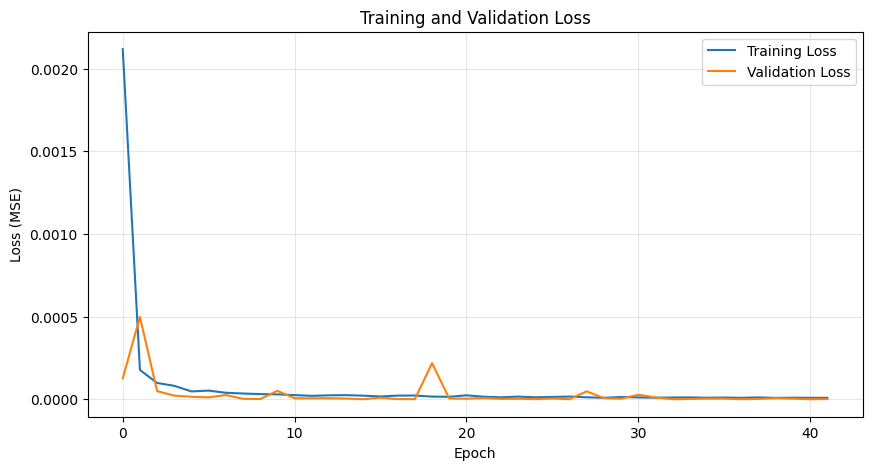

In [ ]:
# Plotting training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('training_loss.png')
plt.show()

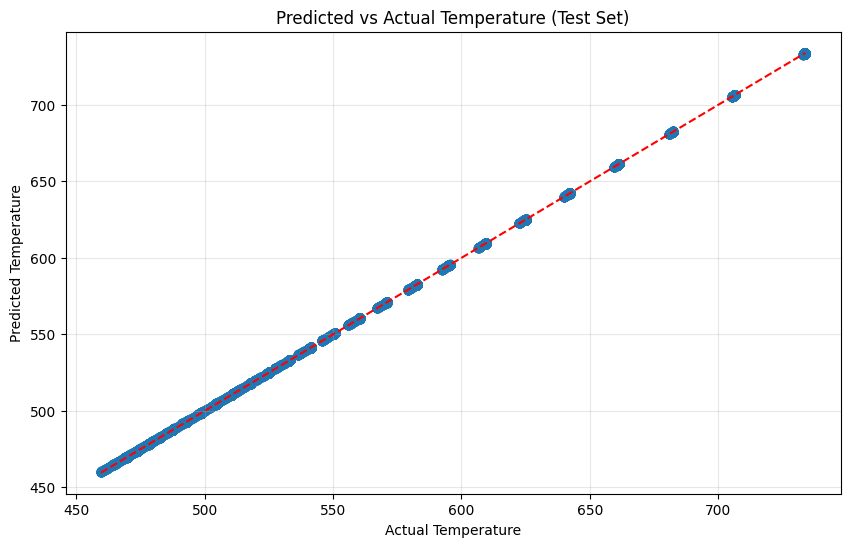

In [ ]:
# Plotting actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(test_actual_np, test_predictions_np, alpha=0.5)
plt.plot([test_actual_np.min(), test_actual_np.max()],
         [test_actual_np.min(), test_actual_np.max()], 'r--')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Predicted vs Actual Temperature (Test Set)')
plt.grid(True, alpha=0.3)

In [ ]:
# Converting test data back to original scale for visualization
X_test_orig = X_test * X_scaler_std + X_scaler_mean
Y_test_orig = Y_test * Y_scaler_std + Y_scaler_mean
H_test_orig = L_test * L_scaler_std + L_scaler_mean

# === STEP 11: Fixed L Slice Visualization ===

✅ Plotting for L = 30 mm


/tmp/ipython-input-1220189656.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


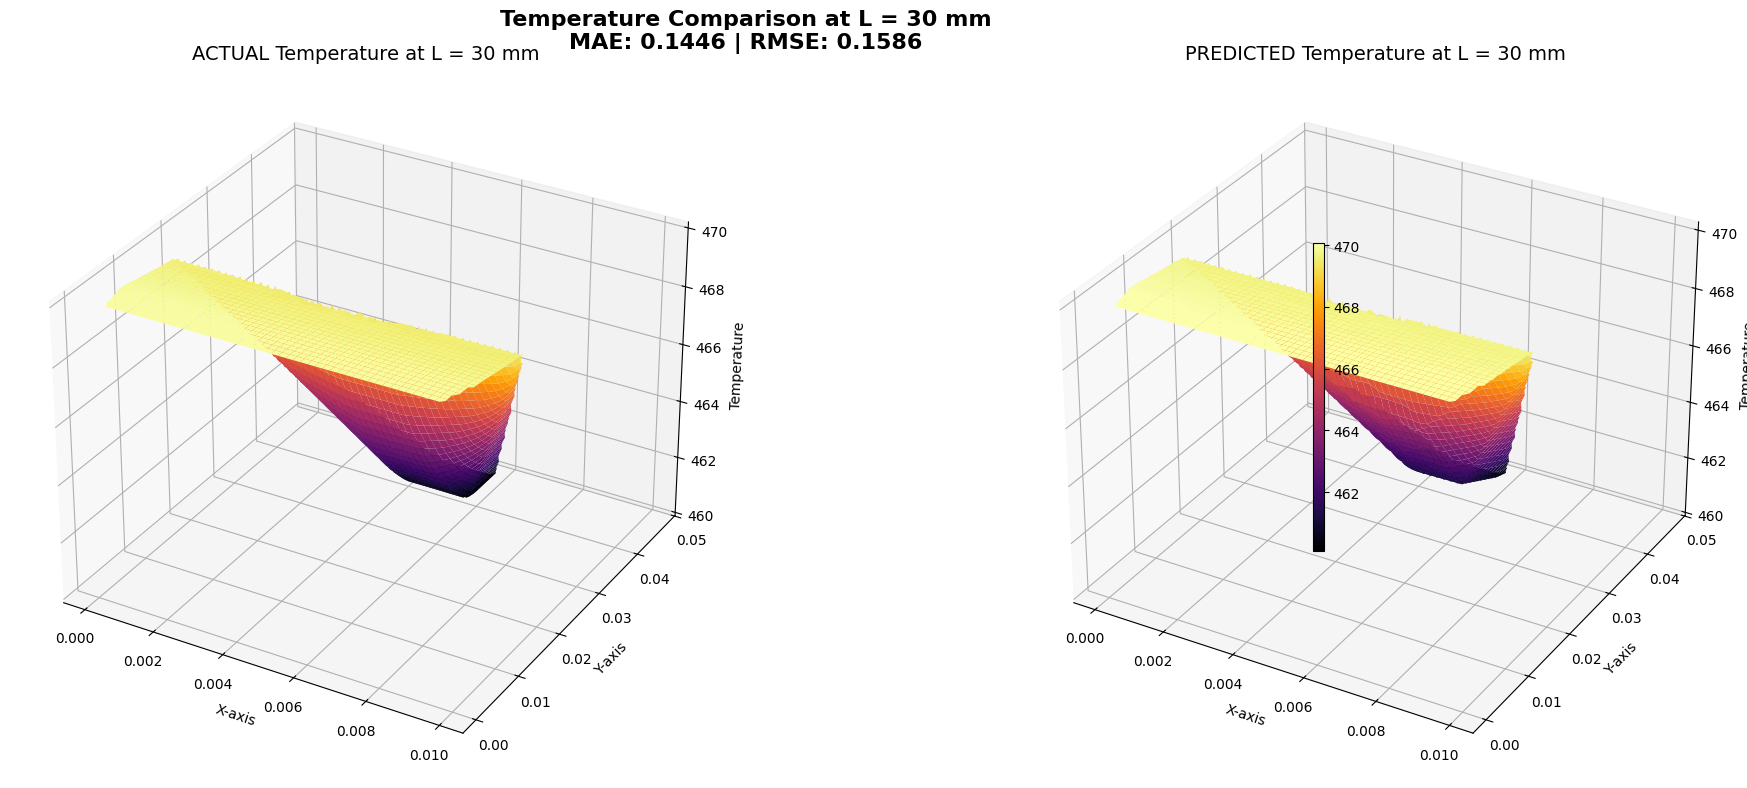

✅ Clean plot saved to: comparison_temperature_L_fixed/comparison_fixed_L30.png


In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np
import os


target_L_value = 30
L_tolerance = 0.5
output_folder = "comparison_temperature_L_fixed"


L_test_orig = L_test * L_scaler_std + L_scaler_mean
L_mask = np.abs(L_test_orig - target_L_value) <= L_tolerance

if np.sum(L_mask) == 0:
    print(f"❌ No samples for L ≈ {target_L_value} mm")
else:
    print(f"✅ Plotting for L = {target_L_value} mm")


    X_vals = X_test[L_mask] * X_scaler_std + X_scaler_mean
    Y_vals = Y_test[L_mask] * Y_scaler_std + Y_scaler_mean
    T_true = Y_test_tensor[L_mask].cpu().numpy().flatten() * T_scaler_std + T_scaler_mean

    model.eval()
    with torch.no_grad():
        T_pred_tensor = model(X_test_tensor[L_mask])
    T_pred = T_pred_tensor.cpu().numpy().flatten() * T_scaler_std + T_scaler_mean

    # Clip extreme spikes (top/bottom 1%) to remove noise
    t_min = np.percentile(np.concatenate([T_true, T_pred]), 1)
    t_max = np.percentile(np.concatenate([T_true, T_pred]), 99)

    T_true = np.clip(T_true, t_min, t_max)
    T_pred = np.clip(T_pred, t_min, t_max)

    # Grid
    points = np.column_stack((X_vals, Y_vals))
    x_grid = np.linspace(X_vals.min(), X_vals.max(), 100)
    y_grid = np.linspace(Y_vals.min(), Y_vals.max(), 100)
    X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

    # Interpolation with 'linear' instead of 'cubic'
    T_true_grid = griddata(points, T_true, (X_grid, Y_grid), method='linear')
    T_pred_grid = griddata(points, T_pred, (X_grid, Y_grid), method='linear')

    # Unified color scale
    vmin = min(T_true.min(), T_pred.min())
    vmax = max(T_true.max(), T_pred.max())

    # Metrics
    mae = np.mean(np.abs(T_pred - T_true))
    rmse = np.sqrt(np.mean((T_pred - T_true) ** 2))

    # Plot
    fig = plt.figure(figsize=(20, 8))

    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X_grid, Y_grid, T_true_grid, cmap='inferno',
                             vmin=vmin, vmax=vmax, edgecolor='none')
    ax1.set_title(f"ACTUAL Temperature at L = {target_L_value} mm", fontsize=14)
    ax1.set_xlabel("X-axis")
    ax1.set_ylabel("Y-axis")
    ax1.set_zlabel("Temperature")

    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X_grid, Y_grid, T_pred_grid, cmap='inferno',
                             vmin=vmin, vmax=vmax, edgecolor='none')
    ax2.set_title(f"PREDICTED Temperature at L = {target_L_value} mm", fontsize=14)
    ax2.set_xlabel("X-axis")
    ax2.set_ylabel("Y-axis")
    ax2.set_zlabel("Temperature")

    fig.colorbar(surf1, ax=[ax1, ax2], shrink=0.5, aspect=30, pad=0.1)

    fig.suptitle(f"Temperature Comparison at L = {target_L_value} mm\n"
                 f"MAE: {mae:.4f} | RMSE: {rmse:.4f}",
                 fontsize=16, fontweight='bold')

    plt.tight_layout()

    # Save
    os.makedirs(output_folder, exist_ok=True)
    save_path = os.path.join(output_folder, f"comparison_fixed_L{target_L_value}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Clean plot saved to: {save_path}")


In [ ]:
def predict_temperature(x_coord, y_coord, z_coord, l_value, model,
                        X_scaler_mean, X_scaler_std,
                        Y_scaler_mean, Y_scaler_std,
                        Z_scaler_mean, Z_scaler_std,
                        L_scaler_mean, L_scaler_std,
                        T_scaler_mean, T_scaler_std, device):
    """
    Predicts temperature for a given set of coordinates and L value using the trained model.

    Args:
        x_coord, y_coord, z_coord, l_value (float): Input coordinates and L value.
        model (torch.nn.Module): The trained neural network model.
        X_scaler_mean, X_scaler_std, ... (float): Mean and standard deviation for scaling.
        device (torch.device): The device the model is on (cpu or cuda).

    Returns:
        float: Predicted temperature in original units.
    """
    # Scale the input values
    x_scaled = (x_coord - X_scaler_mean) / X_scaler_std
    y_scaled = (y_coord - Y_scaler_mean) / Y_scaler_std
    z_scaled = (z_coord - Z_scaler_mean) / Z_scaler_std
    l_scaled = (l_value - L_scaler_mean) / L_scaler_std

    # Create a tensor from the scaled inputs
    input_tensor = torch.FloatTensor([[x_scaled, y_scaled, z_scaled, l_scaled]]).to(device)

    # Make a prediction with the model
    model.eval()
    with torch.no_grad():
        predicted_scaled_temp = model(input_tensor)

    # Inverse scale the prediction
    predicted_temp = predicted_scaled_temp.cpu().numpy() * T_scaler_std + T_scaler_mean

    return predicted_temp[0][0]

# Example usage:
# Replace these values with the desired coordinates and L
example_x = 0.0003846153846
example_y = 0.006611111111
example_z = 0.008846153846
example_l = 15.0

predicted_temperature = predict_temperature(
    example_x, example_y, example_z, example_l, model,
    X_scaler_mean, X_scaler_std, Y_scaler_mean, Y_scaler_std,
    Z_scaler_mean, Z_scaler_std, L_scaler_mean, L_scaler_std,
    T_scaler_mean, T_scaler_std, device
)

print(f"Predicted temperature for X={example_x}, Y={example_y}, Z={example_z}, L={example_l}: {predicted_temperature:.4f}")

Predicted temperature for X=0.0003846153846, Y=0.006611111111, Z=0.008846153846, L=28.38: 476.2053
